# [Super AI Engineer Season 6] Mini Hackathon 2 Level 2
## Parasite Eggs Classification (SAHI / Patch-based Approach)

**Super AI Engineer Season 6 - Level 2 Hackathon**  
- Dataset: Chula-ParasiteEgg-11 + Competition Test Set  
- จัดทำโดย: 600425-วิศิษฐ์

---
### 🚨 The Secret to this Hackathon: "Small Object in Large Image"
ผู้เข้าแข่งขันคนอื่นที่ได้คะแนนสูงใช้ **YOLOv8** (Object Detection) หรือ **SAHI + ResNet50** (Slicing Aided Hyper Inference) เพราะ:
1. **Train Data:** เป็นภาพไข่พยาธิที่ถูก **Crop ซูมมาแบบพอดีตัว (Tight Crop)**
2. **Test Data:** เป็นภาพขนาดใหญ่ **500x500** ที่มีไข่พยาธิใบเล็กๆ ซ่อนอยู่ท่ามกลาง Background กว้างๆ
> ❌ **ถ้าเรา Resize ภาพ Test 500x500 ให้เหลือ 224x224 ไข่พยาธิจะหดเล็กลงจนมองไม่เห็น ทำให้โมเดล Classifier ปกติทายผิดหมด (คะแนน 0.04)**
> ✅ **วิธีแก้:** เราจะใช้เทคนิค **Sliding Window (ตัดภาพ Test เป็นช่องเล็กๆ)** เหมือนที่ SAHI ทำ แล้วเอา Classifier ไปสแกนหาพยาธิทีละช่อง!

### Notebook Outline
1. Setup & Imports
2. Data Preparation
3. Model Training (EfficientNet-B4)
4. Slicing Aided Inference (Patch-based Scanning)
5. Submission

# 1. Setup & Imports

In [1]:
!pip install -q timm

import os, random, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from torchvision import transforms
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CLASSES = [
    "Ascaris lumbricoides",       # 0
    "Capillaria philippinensis",  # 1
    "Enterobius vermicularis",    # 2
    "Fasciolopsis buski",         # 3
    "Hookworm egg",               # 4
    "Hymenolepis diminuta",       # 5
    "Hymenolepis nana",           # 6
    "Opisthorchis viverrine",     # 7
    "Paragonimus spp",            # 8
    "Taenia spp. egg",            # 9
    "Trichuris trichiura",        # 10
]
NUM_CLASSES = len(CLASSES)
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}
IDX2CLASS  = {i: c for i, c in enumerate(CLASSES)}

TRAIN_DIR  = Path('/kaggle/input/datasets/macharning/chula-parasite-dataset/Chula-ParasiteEgg-11/Chula-ParasiteEgg-11/Chula-ParasiteEgg-11/data')
TEST_DIR   = Path('/kaggle/input/competitions/super-ai-engineer-season-6-parasite-eggs/test_set/test')
SAMPLE_SUB = Path('/kaggle/input/competitions/super-ai-engineer-season-6-parasite-eggs/sample_submission.csv')

# Hyperparameters
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 15

# 2. Data Loading & Preparation

In [2]:
# ── 1. Load Training Data ──────────────────────────────────────────────────
all_paths, all_labels = [], []
if TRAIN_DIR.exists():
    img_files = list(TRAIN_DIR.glob('*.jpg')) + list(TRAIN_DIR.glob('*.png'))
    for p in img_files:
        matched = None
        for c in CLASSES:
            if p.name.startswith(c):
                matched = c; break
        if matched:
            all_paths.append(p)
            all_labels.append(CLASS2IDX[matched])

print(f'Training Images: {len(all_paths):,}')

# ── 2. Dataset & Augmentation ──────────────────────────────────────────────
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class ParasiteDataset(Dataset):
    def __init__(self, paths, labels=None, tf=None):
        self.paths = paths; self.labels = labels; self.tf = tf
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.tf: img = self.tf(img)
        if self.labels is not None: return img, self.labels[idx]
        return img

tr_p, vl_p, tr_l, vl_l = train_test_split(all_paths, all_labels, test_size=0.15, stratify=all_labels, random_state=SEED)
tr_loader = DataLoader(ParasiteDataset(tr_p, tr_l, train_tf), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
vl_loader = DataLoader(ParasiteDataset(vl_p, vl_l, val_tf), batch_size=64, num_workers=2)

Training Images: 11,000


# 3. Model Training (EfficientNet-B4)

In [3]:
model = timm.create_model('efficientnet_b4', pretrained=True, num_classes=NUM_CLASSES).to(DEVICE)

# จัดการ Class Imbalance ด้วย Weights
counts = np.bincount(tr_l, minlength=NUM_CLASSES)
weights = torch.tensor(1.0 / (counts + 1e-6), dtype=torch.float32).to(DEVICE)
weights = weights / weights.sum() * NUM_CLASSES

criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_f1 = 0
for epoch in range(1, EPOCHS + 1):
    model.train()
    for imgs, lbls in tr_loader:
        optimizer.zero_grad()
        criterion(model(imgs.to(DEVICE)), lbls.to(DEVICE)).backward()
        optimizer.step()
    scheduler.step()

    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for imgs, lbls in vl_loader:
            out = model(imgs.to(DEVICE))
            preds.extend(out.argmax(1).cpu().numpy())
            gts.extend(lbls.numpy())

    from sklearn.metrics import f1_score
    f1 = f1_score(gts, preds, average='macro')
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), 'best_model.pth')
    print(f'Epoch {epoch:02d} | Val F1: {f1:.4f}')

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Epoch 01 | Val F1: 0.9229
Epoch 02 | Val F1: 0.9591
Epoch 03 | Val F1: 0.9739
Epoch 04 | Val F1: 0.9818
Epoch 05 | Val F1: 0.9824
Epoch 06 | Val F1: 0.9879
Epoch 07 | Val F1: 0.9873
Epoch 08 | Val F1: 0.9878
Epoch 09 | Val F1: 0.9897
Epoch 10 | Val F1: 0.9873
Epoch 11 | Val F1: 0.9909
Epoch 12 | Val F1: 0.9909
Epoch 13 | Val F1: 0.9903
Epoch 14 | Val F1: 0.9921
Epoch 15 | Val F1: 0.9909


# 4. Slicing Aided Inference (The Secret Weapon)
### แทนที่จะป้อนภาพ 500x500 เข้าไปทีเดียว เราจะตัดภาพเป็นแผ่นเล็กๆ (Patch) ขนาด 150x150 แล้วให้โมเดลสแกนทีละแผ่น ถ้าแผ่นไหนมีความมั่นใจสูงสุด เราจะถือว่าแผ่นนั้นเจอพยาธิ

In [4]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# ── การตั้งค่า Slicing (Sliding Window) ───────────────────────────────────
PATCH_SIZE = 180   # ขนาด Crop ให้ใกล้เคียงกับไข่พยาธิ
STRIDE     = 80    # ระยะการเลื่อน (ยิ่งน้อยยิ่งละเอียด แต่สแกนเยอะขึ้น)
THRESHOLD  = 0.75  # ต้องมั่นใจเกิน 75% ถึงจะยอมรับว่าเจอพยาธิ (กัน Background หลอก)

test_files = sorted(TEST_DIR.glob('*.png'))
final_predictions = {}
final_confidences = {}

print(f"Scanning {len(test_files)} images using SAHI-style patches...")

with torch.no_grad():
    for path in tqdm(test_files):
        img = Image.open(path).convert('RGB')
        w, h = img.size
        
        patches = []
        # ตัดภาพ (Slicing) เหมือนเอาแว่นขยายส่องไปทั่วๆ
        for y in range(0, h - PATCH_SIZE + 1, STRIDE):
            for x in range(0, w - PATCH_SIZE + 1, STRIDE):
                patch = img.crop((x, y, x + PATCH_SIZE, y + PATCH_SIZE))
                patches.append(val_tf(patch))
        
        # ถ้ารูปเล็กกว่า Patch (กันเหนียว) ให้ใส่รูปเต็มไปด้วย
        patches.append(val_tf(img))
        
        batch = torch.stack(patches).to(DEVICE)
        logits = model(batch)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        
        # หา Patch ที่โมเดลมั่นใจที่สุดในรูปนี้
        max_probs = probs.max(axis=1)        # ความมั่นใจสูงสุดของแต่ละ patch
        best_patch_idx = max_probs.argmax()  # index ของ patch ที่มั่นใจสุด
        
        best_conf = max_probs[best_patch_idx]
        best_class = probs[best_patch_idx].argmax()
        
        # ถ้าความมั่นใจสูงสุดยังไม่ผ่าน Threshold แปลว่ามีแต่ Background
        if best_conf >= THRESHOLD:
            final_predictions[path.name] = best_class
        else:
            final_predictions[path.name] = -1
            
        final_confidences[path.name] = best_conf

Scanning 2002 images using SAHI-style patches...


  0%|          | 0/2002 [00:00<?, ?it/s]

# 5. Submission

Inference Complete!
Rejected (-1): 671 images
Prediction distribution:
label
-1     671
 0       1
 1     613
 2     127
 3     206
 4      13
 5      33
 6     190
 7      79
 8      18
 9      48
 10      1
Name: count, dtype: int64


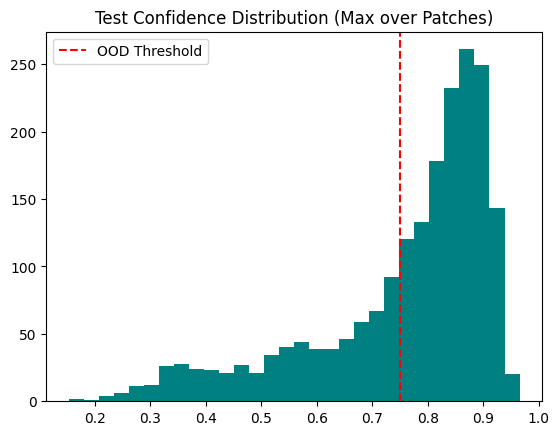

In [5]:
sub = pd.read_csv(SAMPLE_SUB)
sub['label'] = sub['filename'].map(final_predictions)
sub['label'] = sub['label'].fillna(-1).astype(int)

sub.to_csv('submission.csv', index=False)

print("Inference Complete!")
print(f"Rejected (-1): {(sub['label'] == -1).sum()} images")
print("Prediction distribution:")
print(sub['label'].value_counts().sort_index())

# เช็คความมั่นใจ
confs = list(final_confidences.values())
plt.hist(confs, bins=30, color='teal')
plt.axvline(THRESHOLD, color='red', linestyle='--', label='OOD Threshold')
plt.title('Test Confidence Distribution (Max over Patches)')
plt.legend(); plt.show()